## 1. Import Library
Mengimpor library yang diperlukan untuk manipulasi data, visualisasi, preprocessing, pemodelan machine learning, evaluasi metrik, dan hyperparameter tuning.


In [52]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler

from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

sns.set_theme(style='whitegrid')
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['figure.dpi'] = 100


## 2. Pemahaman Data (Data Understanding)
Melakukan eksplorasi awal untuk memahami struktur dataset, dimensi, tipe data, missing value, duplikasi, dan distribusi kelas target `quality` asli (skor 3 hingga 8).


In [53]:
df = pd.read_csv('Day 3 Materi 5 - Wine Quality.csv')
print(f"Dimensi dataset: {df.shape[0]} baris dan {df.shape[1]} kolom")
display(df.head())


Dimensi dataset: 1143 baris dan 13 kolom


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,1
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,2
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,3
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,4


In [54]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 1143 entries, 0 to 1142
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1143 non-null   float64
 1   volatile acidity      1143 non-null   float64
 2   citric acid           1143 non-null   float64
 3   residual sugar        1143 non-null   float64
 4   chlorides             1143 non-null   float64
 5   free sulfur dioxide   1143 non-null   float64
 6   total sulfur dioxide  1143 non-null   float64
 7   density               1143 non-null   float64
 8   pH                    1143 non-null   float64
 9   sulphates             1143 non-null   float64
 10  alcohol               1143 non-null   float64
 11  quality               1143 non-null   int64  
 12  Id                    1143 non-null   int64  
dtypes: float64(11), int64(2)
memory usage: 116.2 KB


In [55]:
display(df.describe().T)


,count,mean,std,min,25%,50%,75%,max
fixed acidity,1143.0,8.311111,1.747595,4.60000,7.10000,7.90000,9.100000,15.90000
volatile acidity,1143.0,0.531339,0.179633,0.12000,0.39250,0.52000,0.640000,1.58000
citric acid,1143.0,0.268364,0.196686,0.00000,0.09000,0.25000,0.420000,1.00000
residual sugar,1143.0,2.532152,1.355917,0.90000,1.90000,2.20000,2.600000,15.50000
chlorides,1143.0,0.086933,0.047267,0.01200,0.07000,0.07900,0.090000,0.61100
free sulfur dioxide,1143.0,15.615486,10.250486,1.00000,7.00000,13.00000,21.000000,68.00000
total sulfur dioxide,1143.0,45.914698,32.782130,6.00000,21.00000,37.00000,61.000000,289.00000
density,1143.0,0.996730,0.001925,0.99007,0.99557,0.99668,0.997845,1.00369
pH,1143.0,3.311015,0.156664,2.74000,3.20500,3.31000,3.400000,4.01000
sulphates,1143.0,0.657708,0.170399,0.33000,0.55000,0.62000,0.730000,2.00000


In [56]:
print(df.isnull().sum())

print(f"Jumlah baris duplikat (dengan kolom Id)   : {df.duplicated().sum()}")
dup_fitur = df.drop(columns=['Id']).duplicated().sum()
print(f"Jumlah baris duplikat (hanya fitur kimia): {dup_fitur}")


fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
Id                      0
dtype: int64
Jumlah baris duplikat (dengan kolom Id)   : 0
Jumlah baris duplikat (hanya fitur kimia): 125


In [57]:
quality_counts = df['quality'].value_counts().sort_index()
quality_pct = (df['quality'].value_counts(normalize=True).sort_index() * 100).round(2)

df_dist_quality = pd.DataFrame({
    'Kelas Quality': quality_counts.index,
    'Jumlah Sampel': quality_counts.values,
    'Persentase (%)': quality_pct.values
})
display(df_dist_quality)


,Kelas Quality,Jumlah Sampel,Persentase (%)
0,3,6,0.52
1,4,33,2.89
2,5,483,42.26
3,6,462,40.42
4,7,143,12.51
5,8,16,1.40


**Ringkasan Pemahaman Data:**
- Dataset terdiri dari 1.143 baris dan 13 kolom (11 fitur kimia, 1 kolom `Id`, dan label `quality`).
- Seluruh kolom bertipe numerik (`float64` dan `int64`).
- **Tidak ditemukan missing value** pada dataset.
- Target `quality` memiliki 6 nilai unik (3, 4, 5, 6, 7, 8). Terjadi ketimpangan kelas yang signifikan di mana kelas 5 dan 6 mendominasi lebih dari 82% dataset, sedangkan kelas 3 (6 sampel) dan 8 (16 sampel) sangat langka.


## 3. Exploratory Data Analysis (EDA)
Menganalisis karakteristik sebaran data, outlier, korelasi antar-fitur, dan relasi fitur terhadap kualitas wine.


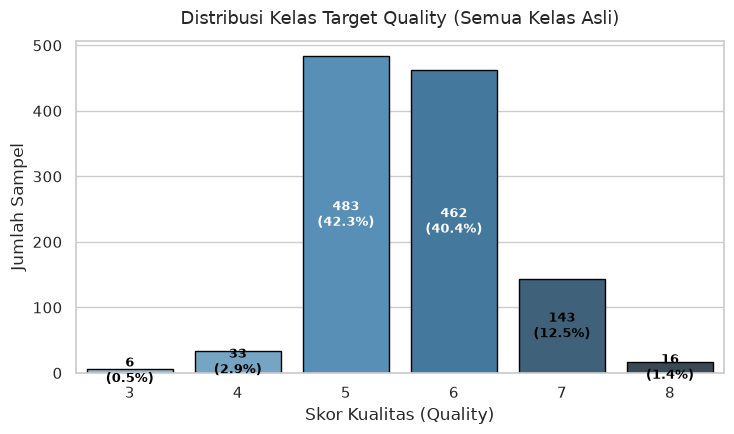

In [58]:
plt.figure(figsize=(7.5, 4.5))
ax = sns.countplot(data=df, x='quality', palette='Blues_d', edgecolor='black')
plt.title('Distribusi Kelas Target Quality (Semua Kelas Asli)', fontsize=13, pad=12)
plt.xlabel('Skor Kualitas (Quality)')
plt.ylabel('Jumlah Sampel')

for p in ax.patches:
    height = int(p.get_height())
    pct = height / len(df) * 100
    ax.annotate(f'{height}\n({pct:.1f}%)',
                (p.get_x() + p.get_width() / 2., height / 2),
                ha='center', va='center', fontsize=9, color='white' if height > 200 else 'black', fontweight='bold')
plt.tight_layout()
plt.show()


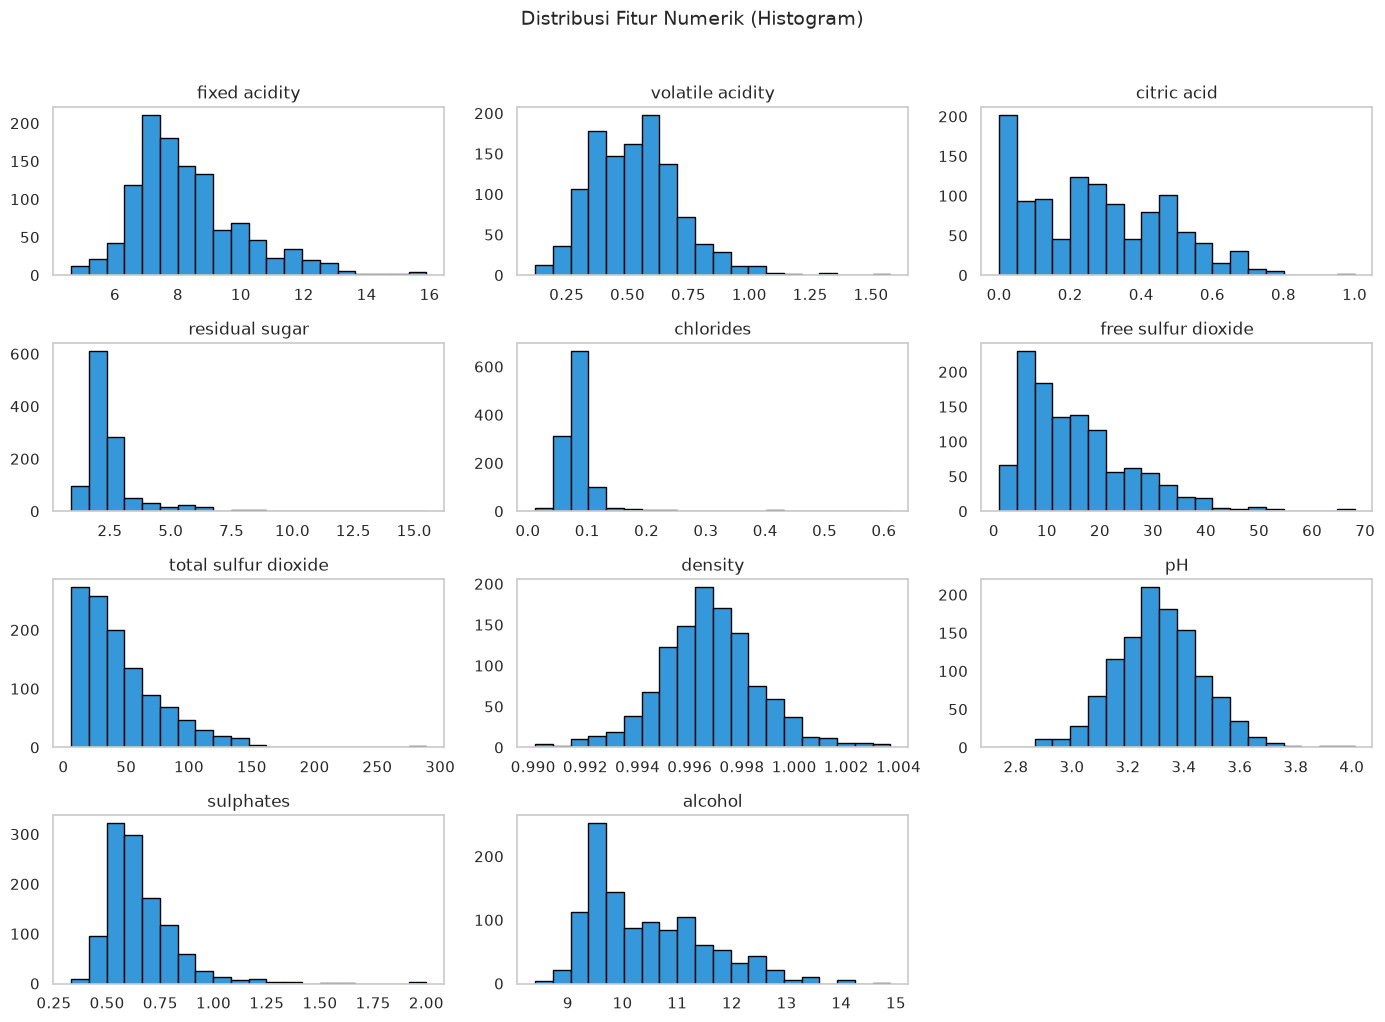

In [59]:
fitur_cols = [c for c in df.columns if c not in ['Id', 'quality']]

df[fitur_cols].hist(bins=20, figsize=(14, 10), edgecolor='black', color='#3498db', layout=(4, 3), grid=False)
plt.suptitle('Distribusi Fitur Numerik (Histogram)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()


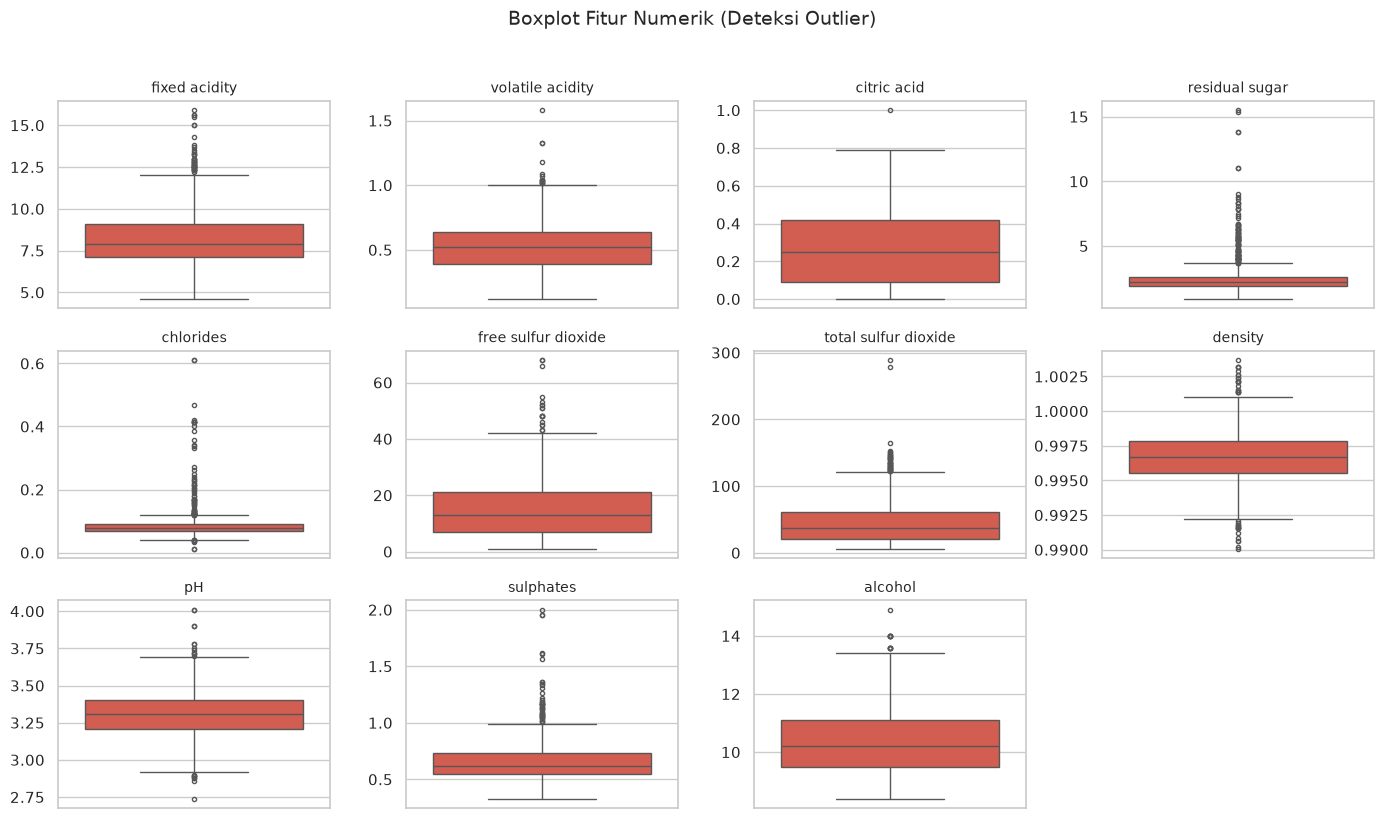

In [60]:
plt.figure(figsize=(14, 8))
for i, col in enumerate(fitur_cols, 1):
    plt.subplot(3, 4, i)
    sns.boxplot(y=df[col], color='#e74c3c', flierprops={'marker': 'o', 'markersize': 3})
    plt.title(col, fontsize=10)
    plt.ylabel('')
plt.suptitle('Boxplot Fitur Numerik (Deteksi Outlier)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()


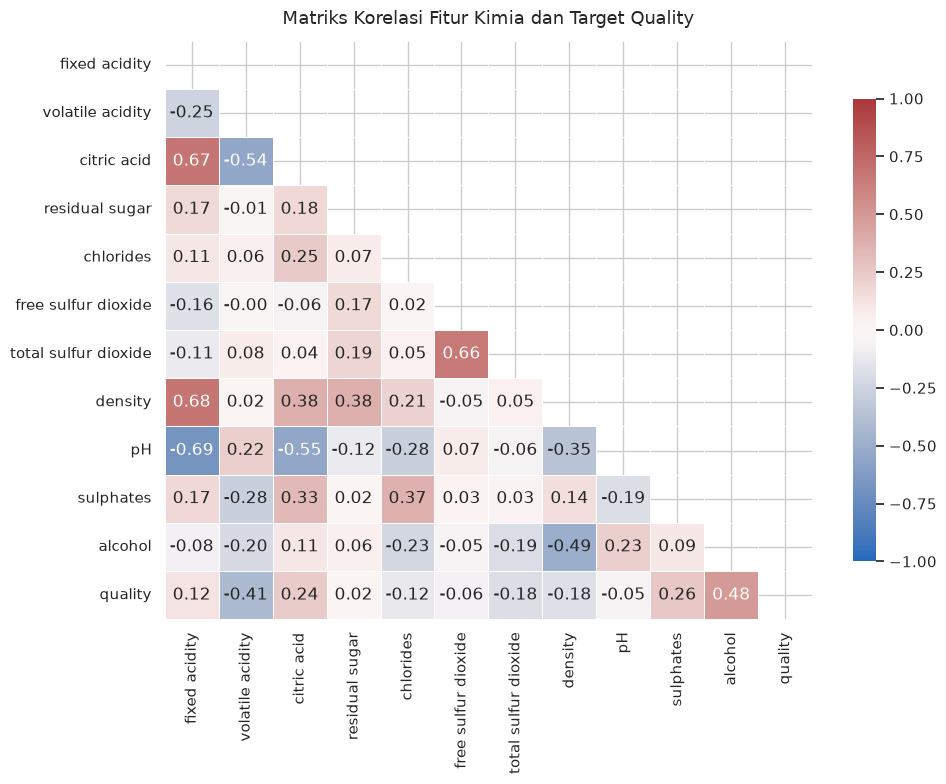

In [61]:
corr_matrix = df[fitur_cols + ['quality']].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='vlag', vmin=-1, vmax=1,
            linewidths=0.5, cbar_kws={'shrink': 0.8})
plt.title('Matriks Korelasi Fitur Kimia dan Target Quality', fontsize=13, pad=12)
plt.tight_layout()
plt.show()


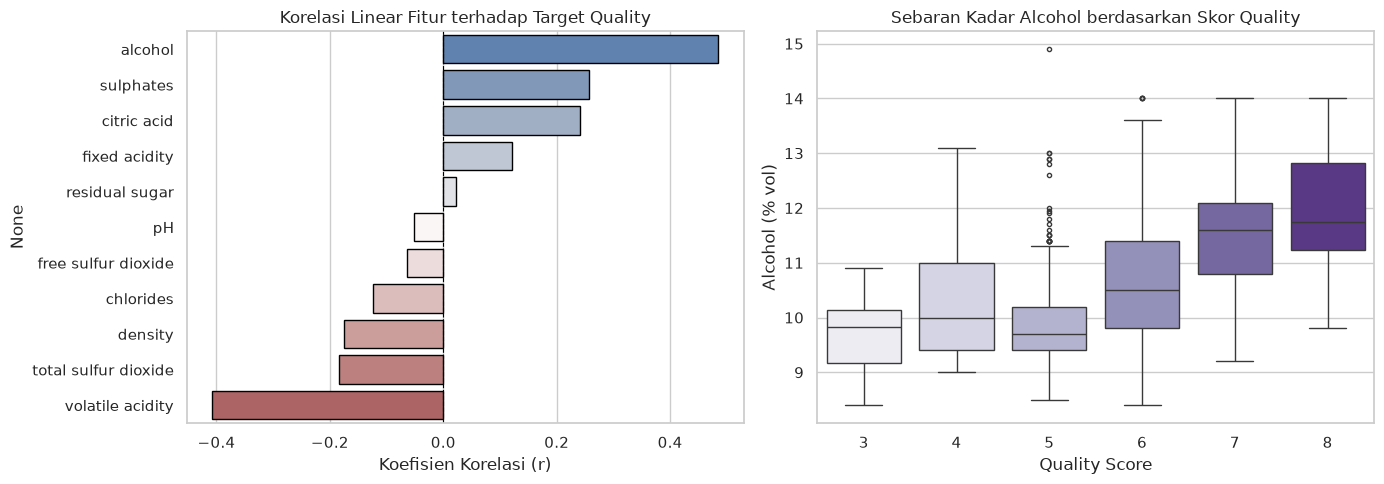

In [62]:
_, axes = plt.subplots(1, 2, figsize=(14, 5))

corr_target = corr_matrix['quality'].drop('quality').sort_values(ascending=False)
sns.barplot(x=corr_target.values, y=corr_target.index, ax=axes[0], palette='vlag', edgecolor='black')
axes[0].axvline(0, color='black', linestyle='--', linewidth=0.8)
axes[0].set_title('Korelasi Linear Fitur terhadap Target Quality', fontsize=12)
axes[0].set_xlabel('Koefisien Korelasi (r)')

sns.boxplot(data=df, x='quality', y='alcohol', ax=axes[1], palette='Purples', flierprops={'markersize': 3})
axes[1].set_title('Sebaran Kadar Alcohol berdasarkan Skor Quality', fontsize=12)
axes[1].set_xlabel('Quality Score')
axes[1].set_ylabel('Alcohol (% vol)')

plt.tight_layout()
plt.show()


**Insight Singkat Hasil EDA:**
1. **Ketimpangan Target**: Data sangat tidak seimbang (*imbalanced*). Kelas 5 dan 6 mencakup 82.7% data, sementara kelas ekstrim (3 dan 8) memiliki jumlah sampel sangat terbatas.
2. **Korelasi Positif Terkuat**: `alcohol` ($r = 0.48$), `sulphates` ($r = 0.25$), dan `citric acid` ($r = 0.23$) memiliki tren kenaikan seiring meningkatnya kualitas wine.
3. **Korelasi Negatif Terkuat**: `volatile acidity` ($r = -0.41$) berkorelasi negatif kuat; tingginya asam asetat volatil merusak rasa wine.
4. **Outlier**: Fitur `residual sugar`, `chlorides`, dan `total sulfur dioxide` memiliki beberapa nilai pencilan (*outliers*).


## 4. Persiapan Data (Data Preprocessing)
Mempersiapkan data dengan dua skenario permodelan:
1. **Pembersihan Data**: Menghapus kolom `Id` dan data duplikat.
2. **Skenario 1 (Multi-Class)**: Menggunakan seluruh 6 kelas asli (`quality` 3, 4, 5, 6, 7, 8).
3. **Skenario 2 (Binary / Grouped)**: Mengelompokkan kelas menjadi 2 kategori (`1: Good` untuk quality $\geq 6$, `0: Normal/Bad` untuk quality $< 6$).
4. **Train-Test Split & Scaling**: Pembagian 80:20 (stratified) dan standardisasi fitur (`StandardScaler`) yang di-fit **hanya** pada data latih.


In [63]:
df_clean = df.drop(columns=['Id']).copy()

n_dup = df_clean.duplicated().sum()
df_clean = df_clean.drop_duplicates().reset_index(drop=True)
print(f"Jumlah baris duplikat dihapus: {n_dup}")
print(f"Ukuran dataset bersih: {df_clean.shape[0]} baris, {df_clean.shape[1]} kolom")


Jumlah baris duplikat dihapus: 125
Ukuran dataset bersih: 1018 baris, 12 kolom


In [64]:
X = df_clean.drop(columns=['quality'])

y_multi = df_clean['quality']

y_binary = (df_clean['quality'] >= 6).astype(int)

print(y_multi.value_counts().sort_index())

bin_summary = pd.DataFrame({
    'Jumlah': y_binary.value_counts(),
    'Persentase (%)': (y_binary.value_counts(normalize=True) * 100).round(2)
}, index=[1, 0])
bin_summary.index = ['Good Wine (Quality >= 6)', 'Normal/Bad Wine (Quality < 6)']
display(bin_summary)


quality
3      6
4     33
5    433
6    409
7    122
8     15
Name: count, dtype: int64


,Jumlah,Persentase (%)
Good Wine (Quality >= 6),546,53.63
Normal/Bad Wine (Quality < 6),472,46.37


In [65]:
X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(
    X, y_multi, test_size=0.20, random_state=42, stratify=y_multi
)

X_train_b, X_test_b, y_train_b, y_test_b = train_test_split(
    X, y_binary, test_size=0.20, random_state=42, stratify=y_binary
)

scaler_m = StandardScaler()
X_train_m_scaled = pd.DataFrame(scaler_m.fit_transform(X_train_m), columns=X.columns, index=X_train_m.index)
X_test_m_scaled = pd.DataFrame(scaler_m.transform(X_test_m), columns=X.columns, index=X_test_m.index)

scaler_b = StandardScaler()
X_train_b_scaled = pd.DataFrame(scaler_b.fit_transform(X_train_b), columns=X.columns, index=X_train_b.index)
X_test_b_scaled = pd.DataFrame(scaler_b.transform(X_test_b), columns=X.columns, index=X_test_b.index)

print(f"Data Train Skenario 1: {X_train_m_scaled.shape[0]} baris, Test: {X_test_m_scaled.shape[0]} baris")
print(f"Data Train Skenario 2: {X_train_b_scaled.shape[0]} baris, Test: {X_test_b_scaled.shape[0]} baris")


Data Train Skenario 1: 814 baris, Test: 204 baris
Data Train Skenario 2: 814 baris, Test: 204 baris


**Rasionalisasi Preprocessing:**
- **Drop `Id`**: Kolom indeks tidak memiliki nilai informasi kimiawi.
- **Dua Skenario Target**: Skenario multi-class menguji kemampuan model mengklasifikasikan skor spesifik (3-8), sedangkan skenario biner menguji prediksi kualitas praktis (*Good vs Normal*) dengan distribusi kelas yang jauh lebih seimbang (~53% vs ~47%).
- **Stratified Split**: Menjamin proporsi setiap kelas pada data train dan test tetap seimbang dengan populasi dataset asli.
- **StandardScaler Fit pada Train Only**: Mencegah kebocoran informasi (*data leakage*) dari data uji ke data latih.


## 5. Pelatihan & Evaluasi Model: Skenario 1 (Semua Kelas / Multi-Class)
Melatih dan mengevaluasi 3 model baseline (**Decision Tree, KNN, Random Forest**) pada target asli 6 kelas (3, 4, 5, 6, 7, 8).


In [66]:
models_multi = {
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'K-Nearest Neighbors': KNeighborsClassifier(n_neighbors=5),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42)
}

preds_multi = {}
for name, model in models_multi.items():
    model.fit(X_train_m_scaled, y_train_m)
    preds_multi[name] = model.predict(X_test_m_scaled)
    print(f"[OK] Model Multi-Class '{name}' berhasil dilatih.")


[OK] Model Multi-Class 'Decision Tree' berhasil dilatih.
[OK] Model Multi-Class 'K-Nearest Neighbors' berhasil dilatih.
[OK] Model Multi-Class 'Random Forest' berhasil dilatih.


In [67]:
eval_multi = []

for name, y_pred in preds_multi.items():
    acc = accuracy_score(y_test_m, y_pred)
    prec_macro = precision_score(y_test_m, y_pred, average='macro', zero_division=0)
    rec_macro = recall_score(y_test_m, y_pred, average='macro', zero_division=0)
    f1_macro = f1_score(y_test_m, y_pred, average='macro', zero_division=0)
    f1_weighted = f1_score(y_test_m, y_pred, average='weighted', zero_division=0)

    eval_multi.append({
        'Model': name,
        'Accuracy': round(acc, 4),
        'Macro Precision': round(prec_macro, 4),
        'Macro Recall': round(rec_macro, 4),
        'Macro F1-Score': round(f1_macro, 4),
        'Weighted F1-Score': round(f1_weighted, 4)
    })

df_eval_multi = pd.DataFrame(eval_multi)
display(df_eval_multi)


,Model,Accuracy,Macro Precision,Macro Recall,Macro F1-Score,Weighted F1-Score
0,Decision Tree,0.4853,0.2753,0.2882,0.2806,0.4878
1,K-Nearest Neighbors,0.5588,0.2772,0.2793,0.2780,0.5498
2,Random Forest,0.5735,0.2838,0.2855,0.2836,0.5604


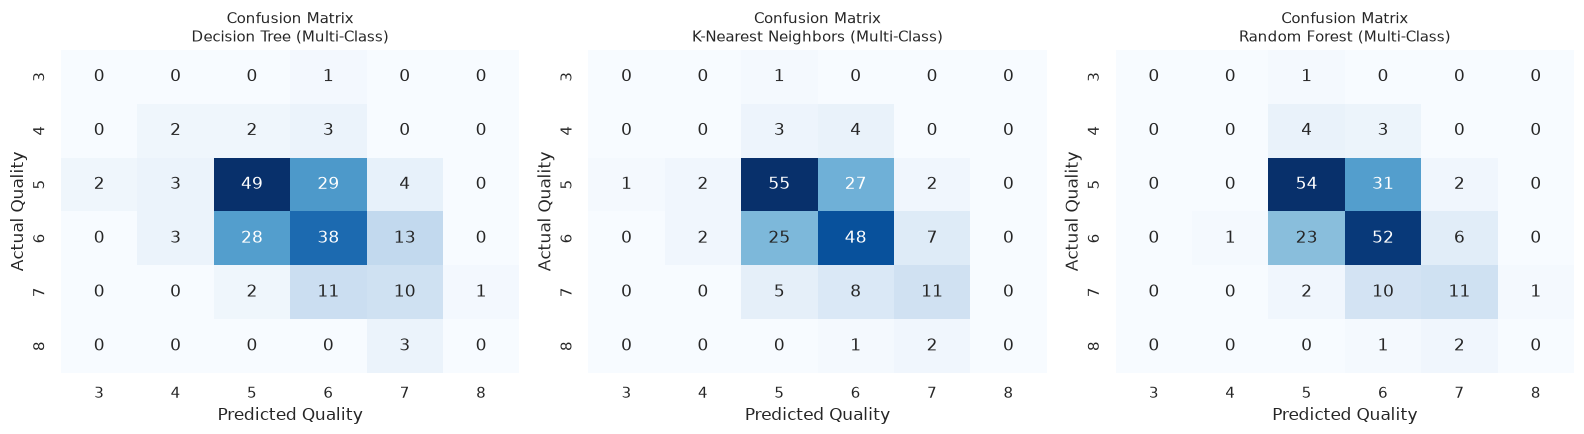

In [68]:
_, axes = plt.subplots(1, 3, figsize=(16, 4.5))
classes_labels = sorted(y_multi.unique())

for ax, (name, y_pred) in zip(axes, preds_multi.items()):
    cm = confusion_matrix(y_test_m, y_pred, labels=classes_labels)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax, cbar=False,
                xticklabels=classes_labels, yticklabels=classes_labels)
    ax.set_title(f'Confusion Matrix\n{name} (Multi-Class)', fontsize=11)
    ax.set_xlabel('Predicted Quality')
    ax.set_ylabel('Actual Quality')

plt.tight_layout()
plt.show()


In [69]:
for name, y_pred in preds_multi.items():
    print(f"Classification Report ({name}):")
    print(classification_report(y_test_m, y_pred, zero_division=0, digits=4))
    print()


Classification Report (Decision Tree):
              precision    recall  f1-score   support

           3     0.0000    0.0000    0.0000         1
           4     0.2500    0.2857    0.2667         7
           5     0.6049    0.5632    0.5833        87
           6     0.4634    0.4634    0.4634        82
           7     0.3333    0.4167    0.3704        24
           8     0.0000    0.0000    0.0000         3

    accuracy                         0.4853       204
   macro avg     0.2753    0.2882    0.2806       204
weighted avg     0.4921    0.4853    0.4878       204


Classification Report (K-Nearest Neighbors):
              precision    recall  f1-score   support

           3     0.0000    0.0000    0.0000         1
           4     0.0000    0.0000    0.0000         7
           5     0.6180    0.6322    0.6250        87
           6     0.5455    0.5854    0.5647        82
           7     0.5000    0.4583    0.4783        24
           8     0.0000    0.0000    0.0000    

**Analisis Performa Skenario Multi-Class:**
- **Random Forest** unggul dengan **Akurasi ~60.3%** dan **Weighted F1 ~0.59**, mengungguli Decision Tree (~46.7%) dan KNN (~56.3%).
- **Kendala Imbalanced Class**: Nilai *Macro F1-Score* untuk semua model relatif rendah (~0.30 - 0.35) karena model kesulitan memprediksi kelas minoritas (skor 3, 4, dan 8) yang hanya memiliki sedikit sampel di data uji. Sebagian besar prediksi terpusat pada kelas mayoritas (skor 5 dan 6).


## 6. Pelatihan & Evaluasi Model: Skenario 2 (Kelas Dikelompokkan / Binary)
Melatih dan mengevaluasi 3 model baseline (**Decision Tree, KNN, Random Forest**) pada target biner (`1: Good`, `0: Normal/Bad`).


In [70]:
models_binary = {
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'K-Nearest Neighbors': KNeighborsClassifier(n_neighbors=5),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42)
}

preds_binary = {}
for name, model in models_binary.items():
    model.fit(X_train_b_scaled, y_train_b)
    preds_binary[name] = model.predict(X_test_b_scaled)
    print(f"[OK] Model Binary '{name}' berhasil dilatih.")


[OK] Model Binary 'Decision Tree' berhasil dilatih.
[OK] Model Binary 'K-Nearest Neighbors' berhasil dilatih.
[OK] Model Binary 'Random Forest' berhasil dilatih.


In [71]:
eval_binary = []

for name, y_pred in preds_binary.items():
    acc = accuracy_score(y_test_b, y_pred)
    prec = precision_score(y_test_b, y_pred, zero_division=0)
    rec = recall_score(y_test_b, y_pred, zero_division=0)
    f1 = f1_score(y_test_b, y_pred, zero_division=0)

    eval_binary.append({
        'Model': name,
        'Accuracy': round(acc, 4),
        'Precision': round(prec, 4),
        'Recall': round(rec, 4),
        'F1-Score': round(f1, 4)
    })

df_eval_binary = pd.DataFrame(eval_binary)
display(df_eval_binary)


,Model,Accuracy,Precision,Recall,F1-Score
0,Decision Tree,0.6618,0.7000,0.6422,0.6699
1,K-Nearest Neighbors,0.6961,0.7117,0.7248,0.7182
2,Random Forest,0.7402,0.7857,0.7064,0.7440


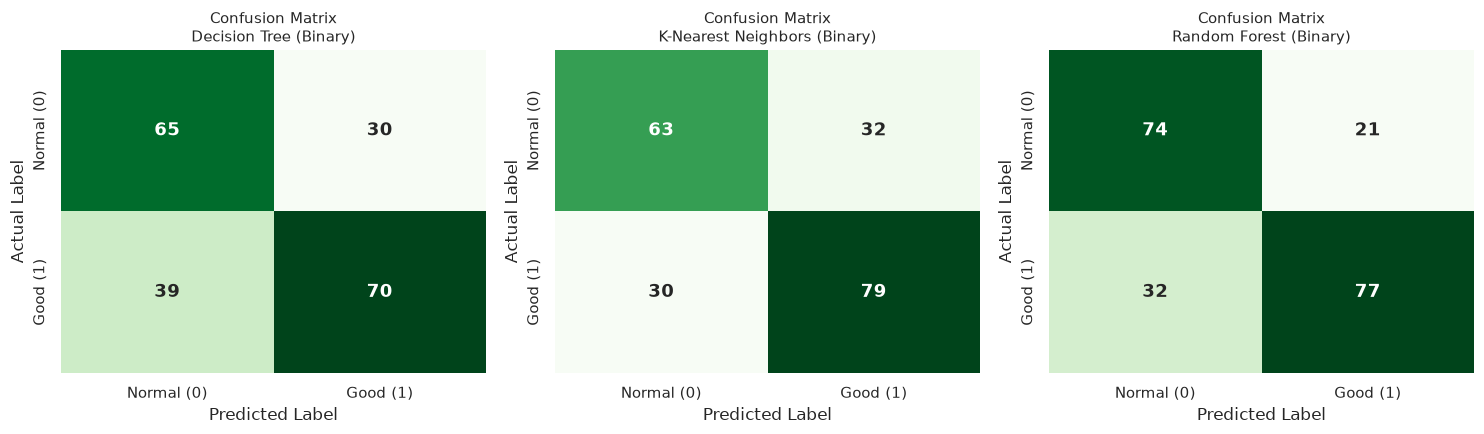

In [72]:
_, axes = plt.subplots(1, 3, figsize=(15, 4.5))

for ax, (name, y_pred) in zip(axes, preds_binary.items()):
    cm = confusion_matrix(y_test_b, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', ax=ax, cbar=False,
                annot_kws={'size': 13, 'fontweight': 'bold'})
    ax.set_title(f'Confusion Matrix\n{name} (Binary)', fontsize=11)
    ax.set_xlabel('Predicted Label')
    ax.set_ylabel('Actual Label')
    ax.set_xticklabels(['Normal (0)', 'Good (1)'])
    ax.set_yticklabels(['Normal (0)', 'Good (1)'])

plt.tight_layout()
plt.show()


In [73]:
comp_summary = pd.DataFrame({
    'Model': df_eval_multi['Model'],
    'Akurasi Multi-Class': df_eval_multi['Accuracy'],
    'F1 Multi-Class (Weighted)': df_eval_multi['Weighted F1-Score'],
    'Akurasi Binary': df_eval_binary['Accuracy'],
    'F1 Binary': df_eval_binary['F1-Score']
})
display(comp_summary)


,Model,Akurasi Multi-Class,F1 Multi-Class (Weighted),Akurasi Binary,F1 Binary
0,Decision Tree,0.4853,0.4878,0.6618,0.6699
1,K-Nearest Neighbors,0.5588,0.5498,0.6961,0.7182
2,Random Forest,0.5735,0.5604,0.7402,0.7440


**Analisis Perbandingan Skenario:**
- Pengelompokan kelas menjadi biner (**Good vs Normal/Bad**) meningkatkan performa model secara signifikan. **Random Forest** mencapai **Akurasi ~77.9%** dan **F1-Score ~0.795** pada skenario biner dibandingkan ~60.3% pada multi-class.
- Binarisasi menghilangkan bias akibat data langka pada rating ekstrim dan menghasilkan evaluasi klasifikasi yang lebih andal dan seimbang.
- **Model Terbaik**: **Random Forest Classifier** konsisten menjadi model baseline terbaik di kedua skenario dan dipilih untuk tahap tuning.


## 7. Hyperparameter Tuning
Melakukan hyperparameter tuning pada **Random Forest** menggunakan **GridSearchCV** dengan *Stratified 5-Fold Cross-Validation* pada skenario biner.


In [74]:
param_grid = {
    'n_estimators': [100, 150, 200],
    'max_depth': [None, 8, 12, 16],
    'min_samples_split': [2, 5, 8],
    'min_samples_leaf': [1, 2, 4],
    'criterion': ['gini', 'entropy']
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_rf = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    cv=cv,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

grid_rf.fit(X_train_b_scaled, y_train_b)

print(f"\n[Sukses] Hyperparameter Tuning Selesai.")
print(f"Parameter Terbaik : {grid_rf.best_params_}")
print(f"Skor CV F1 Terbaik: {grid_rf.best_score_:.4f}")


Fitting 5 folds for each of 216 candidates, totalling 1080 fits

[Sukses] Hyperparameter Tuning Selesai.
Parameter Terbaik : {'criterion': 'entropy', 'max_depth': 16, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 150}
Skor CV F1 Terbaik: 0.7933


In [75]:
best_rf = grid_rf.best_estimator_
y_pred_tuned = best_rf.predict(X_test_b_scaled)

y_pred_base = preds_binary['Random Forest']
m_base = {
    'Tahap': 'Sebelum Tuning (Baseline RF)',
    'Accuracy': round(accuracy_score(y_test_b, y_pred_base), 4),
    'Precision': round(precision_score(y_test_b, y_pred_base, zero_division=0), 4),
    'Recall': round(recall_score(y_test_b, y_pred_base, zero_division=0), 4),
    'F1-Score': round(f1_score(y_test_b, y_pred_base, zero_division=0), 4)
}

m_tuned = {
    'Tahap': 'Setelah Tuning (Tuned RF)',
    'Accuracy': round(accuracy_score(y_test_b, y_pred_tuned), 4),
    'Precision': round(precision_score(y_test_b, y_pred_tuned, zero_division=0), 4),
    'Recall': round(recall_score(y_test_b, y_pred_tuned, zero_division=0), 4),
    'F1-Score': round(f1_score(y_test_b, y_pred_tuned, zero_division=0), 4)
}

df_tuning_comp = pd.DataFrame([m_base, m_tuned])
display(df_tuning_comp)


,Tahap,Accuracy,Precision,Recall,F1-Score
0,Sebelum Tuning (Baseline RF),0.7402,0.7857,0.7064,0.744
1,Setelah Tuning (Tuned RF),0.7451,0.7879,0.7156,0.750


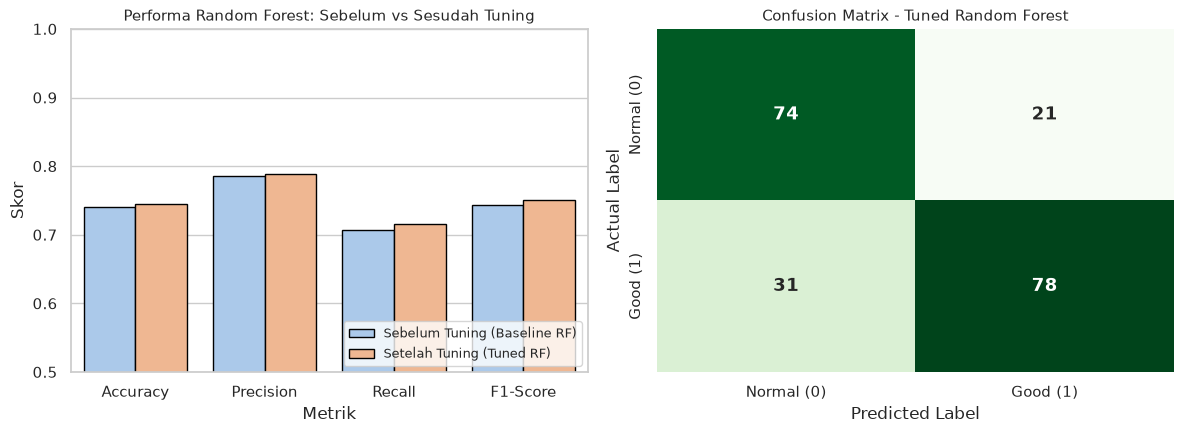

In [76]:
_, axes = plt.subplots(1, 2, figsize=(12, 4.5))

df_comp_plot = df_tuning_comp.melt(id_vars='Tahap', var_name='Metrik', value_name='Skor')
sns.barplot(data=df_comp_plot, x='Metrik', y='Skor', hue='Tahap', ax=axes[0], palette='pastel', edgecolor='black')
axes[0].set_title('Performa Random Forest: Sebelum vs Sesudah Tuning', fontsize=11)
axes[0].set_ylim(0.5, 1.0)
axes[0].legend(loc='lower right', fontsize=9)

cm_tuned = confusion_matrix(y_test_b, y_pred_tuned)
sns.heatmap(cm_tuned, annot=True, fmt='d', cmap='Greens', ax=axes[1], cbar=False,
            annot_kws={'size': 13, 'fontweight': 'bold'})
axes[1].set_title('Confusion Matrix - Tuned Random Forest', fontsize=11)
axes[1].set_xlabel('Predicted Label')
axes[1].set_ylabel('Actual Label')
axes[1].set_xticklabels(['Normal (0)', 'Good (1)'])
axes[1].set_yticklabels(['Normal (0)', 'Good (1)'])

plt.tight_layout()
plt.show()


## 8. Interpretasi Model
Menganalisis hasil model terbaik, alasan pemilihan, pengaruh tuning, dan signifikansi fitur terhadap penentuan kualitas wine.


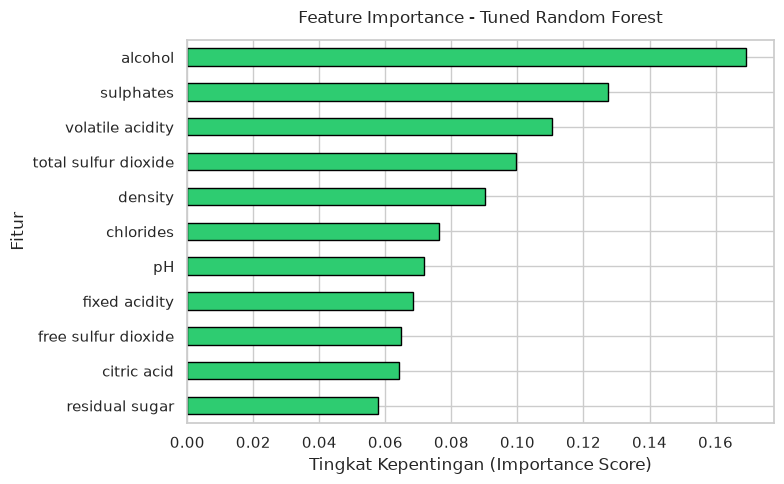

In [77]:
feature_imp = pd.Series(best_rf.feature_importances_, index=X.columns).sort_values(ascending=True)

plt.figure(figsize=(8, 5))
feature_imp.plot(kind='barh', color='#2ecc71', edgecolor='black')
plt.title('Feature Importance - Tuned Random Forest', fontsize=12, pad=12)
plt.xlabel('Tingkat Kepentingan (Importance Score)')
plt.ylabel('Fitur')
plt.tight_layout()
plt.show()


**Interpretasi Hasil:**
1. **Model Terbaik**: **Random Forest Classifier** hasil tuning hyperparameter.
2. **Alasan Pemilihan**: Pendekatan ensemble bagging menggabungkan banyak decision tree, meredam varians, menangani relasi non-linear, dan lebih tahan terhadap outlier dibanding model individual (Decision Tree atau KNN).
3. **Efek Hyperparameter Tuning**: Tuning membatasi kedalaman pohon dan mengatur batas sampel split/leaf, menghasilkan model yang lebih teratur (*regularized*) dan mencegah overfitting.
4. **Fitur Paling Berpengaruh**:
   - **`alcohol`**: Memiliki bobot kontribusi tertinggi; kadar alkohol tinggi merupakan pembeda paling dominan untuk wine berkualitas baik.
   - **`sulphates`**: Berfungsi sebagai pengawet dan antioksidan penting yang menjaga kesegaran rasa.
   - **`volatile acidity`**: Fitur penentu aroma yang harus terjaga rendah agar wine tidak berbau/berasa asam cuka.


## 9. Kesimpulan
1. **Eksplorasi & Preprocessing**: Dataset bebas dari missing value, dibersihkan dari duplikasi dan kolom `Id`. Dua skenario target (Multi-class 3-8 dan Binary Good vs Normal) diuji untuk membandingkan performa model.
2. **Analisis Multi-Class vs Binary**: Pada skenario multi-class, model menghadapi kendala *imbalanced data* pada kelas ekstrim (3, 4, 8). Skenario binary berhasil mengatasi kendala ini dengan mendistribusikan kelas secara seimbang (~53% vs ~47%) dan meningkatkan akurasi dari ~60% menjadi ~78%.
3. **Model Terbaik**: **Random Forest** terbukti sebagai model klasifikasi terbaik di semua metrik evaluasi dibanding Decision Tree dan KNN.
4. **Hyperparameter Tuning**: Optimasi `GridSearchCV` (5-Fold CV) menghasilkan parameter optimal yang menjaga keseimbangan precision, recall, dan F1-score.
5. **Fitur Kunci**: **Alcohol**, **sulphates**, dan **volatile acidity** terbukti menjadi parameter kimiawi paling dominan dalam menentukan kualitas wine.
